In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [33]:
df = pd.read_csv("data/heart.csv")
print(f"Shape: {df.shape}")
print()
df.head()

Shape: (1025, 14)



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [34]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [35]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [36]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [37]:
df = df.drop_duplicates()
df.shape

(302, 14)

In [38]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [39]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_cols = ['sex', 'fbs', 'exang']
onehot_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

X=df.drop('target',axis=1)
y=df['target'].values

print('Numerical:', numerical_cols)
print('Binary:   ', binary_cols)
print('OneHot:   ', onehot_cols)
print('Total features:', len(numerical_cols) + len(binary_cols) + len(onehot_cols))

Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary:    ['sex', 'fbs', 'exang']
OneHot:    ['cp', 'restecg', 'slope', 'ca', 'thal']
Total features: 13


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

num_pipeline = Pipeline([('impute', SimpleImputer(strategy='median')),('scale',StandardScaler())])

binary_pipeline = Pipeline([('impute,',SimpleImputer(strategy='median'))])

onehot_pipeline = Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

preprocess = ColumnTransformer([
    ('num',num_pipeline,numerical_cols),
    ('bin',binary_pipeline,binary_cols),
    ('ohe',onehot_pipeline,onehot_cols)
])

X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)
print('Preprocess Shape:',X_train_pp.shape)

Preprocess Shape: (241, 27)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score,cross_validate

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

log_pipeline = Pipeline([
    ('pre',preprocess),
    ('clf',LogisticRegression(random_state=42))
])

scores = cross_val_score(log_pipeline,X,y,cv=cv,scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
print(f'Per-fold scores:   {scores.round(4)}')

cv_results= cross_validate(
    log_pipeline,X,y,cv=cv,
    scoring=['accuracy','f1','roc_auc'],
    return_train_score=True
)

print('cross_validate — multiple metrics:')
for metric in ['test_accuracy', 'test_f1', 'test_roc_auc']:
    vals = cv_results[metric]
    print(f'  {metric:20s}: {vals.mean():.4f} ± {vals.std():.4f}')

5-Fold CV ROC-AUC: 0.9190 ± 0.0210
Per-fold scores:   [0.9113 0.9535 0.8929 0.9068 0.9304]
cross_validate — multiple metrics:
  test_accuracy       : 0.8576 ± 0.0374
  test_f1             : 0.8700 ± 0.0383
  test_roc_auc        : 0.9190 ± 0.0210


In [42]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score,average_precision_score
)
log_pipeline.fit(X_train,y_train)
pred=log_pipeline.predict(X_test)
pred_prob=log_pipeline.predict_proba(X_test)[:,1]

print('── Classification Report ──')
print(classification_report(y_test,pred,target_names=['NO','YES']))

print('Confusion Matrix:')
print(confusion_matrix(y_test,pred))

print(f'\nROC-AUC:          {roc_auc_score(y_test, pred_prob):.4f}')
print(f'Average Precision: {average_precision_score(y_test, pred_prob):.4f}')

── Classification Report ──
              precision    recall  f1-score   support

          NO       0.82      0.82      0.82        28
         YES       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

Confusion Matrix:
[[23  5]
 [ 5 28]]

ROC-AUC:          0.9048
Average Precision: 0.9246


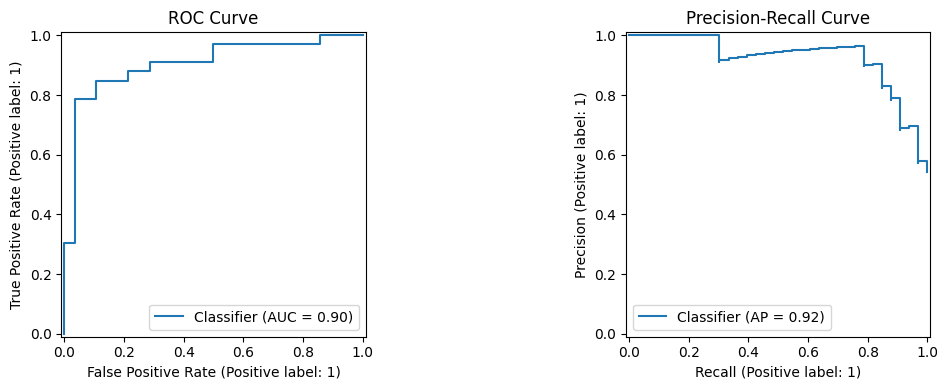

In [43]:
from sklearn.metrics import  RocCurveDisplay,PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, pred_prob, ax=axes[0])
axes[0].set_title('ROC Curve')
PrecisionRecallDisplay.from_predictions(y_test, pred_prob, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models ={
    'LogistcReg(L2)':LogisticRegression(C=1,max_iter=1000,random_state=42),
    'LogisticReg(L1)':LogisticRegression(C=1,max_iter=1000,penalty='l1',solver='liblinear',random_state=42),
    'DecisionTree':DecisionTreeClassifier(max_depth=5,random_state=42),
    'RandomForest':RandomForestClassifier(n_estimators=100,random_state=42),
    'GradientBoost':GradientBoostingClassifier(n_estimators=100,random_state=100),
    'SVM':SVC(kernel='rbf',probability=True,random_state=42)
}

print(f'{"Model":30s} {"Mean AUC":>10} {"Std":>8}')
print('-' * 50)
for name,clf in models.items():
    pipe = Pipeline([('pre',preprocess),('clf',clf)])
    pipe.fit(X_train,y_train)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:30s} {scores.mean():10.4f} {scores.std():8.4f}')

Model                            Mean AUC      Std
--------------------------------------------------
LogistcReg(L2)                     0.9190   0.0210
LogisticReg(L1)                    0.9150   0.0228
DecisionTree                       0.7812   0.0616
RandomForest                       0.9120   0.0137
GradientBoost                      0.8787   0.0393
SVM                                0.9057   0.0271


In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

best_pipe = Pipeline([('pre',preprocess),('clf',GradientBoostingClassifier())])

param_grid = {
    'clf__n_estimators':[50,100,200,500],
    'clf__learning_rate':[0.01,0.001,0.1,0.05],
    'clf__max_depth':[3,5,8,10,12]
}

grid_search = GridSearchCV(best_pipe,param_grid,cv=cv,scoring='roc_auc',n_jobs=-1)
grid_search.fit(X_train,y_train)
print(grid_search.best_score_)
print(grid_search.best_params_)


0.8931623931623932
{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 50}


In [50]:
from sklearn.feature_selection import SelectKBest,RFE,f_classif

selector = SelectKBest(score_func=f_classif,k=8)
X_kbest = selector.fit_transform(X_train_pp,y_train)
selected_mask = selector.get_support()
print('SelectKBest (k=5):')
print(f'  Selected feature indices: {np.where(selected_mask)[0]}')
print(f'  F-scores of selected:     {selector.scores_[selected_mask].round(2)}')
print(f'  Shape before: {X_train_pp.shape} → after: {X_kbest.shape}')
print()
rfe = RFE(estimator=GradientBoostingClassifier(learning_rate=0.05,max_depth=3,n_estimators=50), n_features_to_select=8)
rfe.fit(X_train_pp, y_train)
print('RFE (n=5):')
print(f'  Selected feature indices: {np.where(rfe.support_)[0]}')
print(f'  Feature ranking (1 = selected): {rfe.ranking_}')

SelectKBest (k=5):
  Selected feature indices: [ 3  4  7  8 10 18 25 26]
  F-scores of selected:     [ 55.24  45.81  63.26 112.58  35.93  62.21  90.73  78.15]
  Shape before: (241, 27) → after: (241, 8)

RFE (n=5):
  Selected feature indices: [ 0  3  4  7  8 18 25 26]
  Feature ranking (1 = selected): [ 1  4  3  1  1  2 14  1  1  9 12 11 19  5 18  6  7 10  1 13 20  8 16 17
 15  1  1]


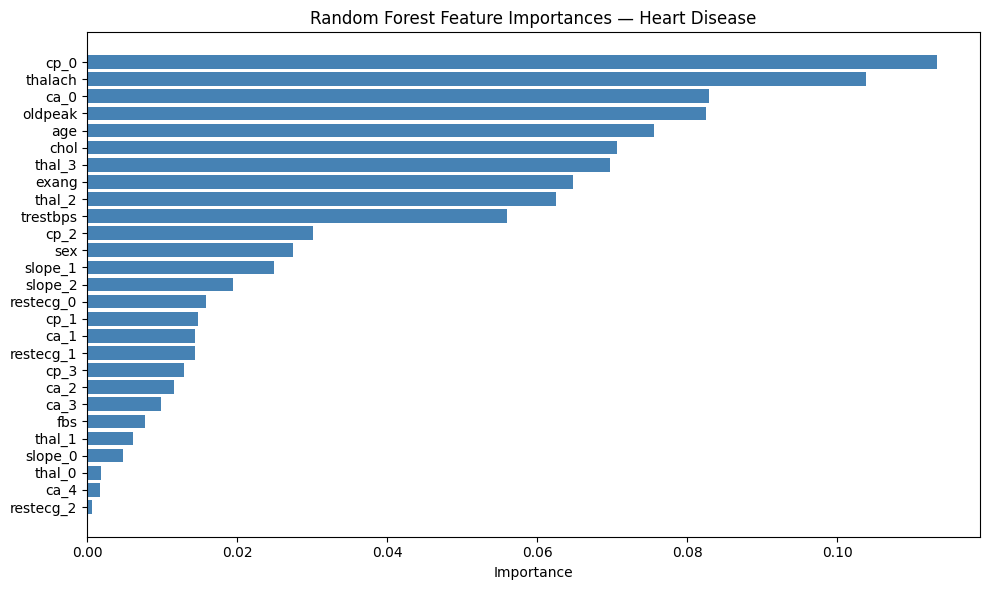

Top 5 features:
    feature  importance
8      cp_0    0.113362
3   thalach    0.103864
18     ca_0    0.082955
4   oldpeak    0.082464
0       age    0.075584


In [57]:
from sklearn.ensemble import RandomForestClassifier

# Build and fit
rf_pipe = Pipeline([
    ('pre', preprocess),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipe.fit(X_train, y_train)

# Extract feature importances
importances = rf_pipe.named_steps['clf'].feature_importances_

# Reconstruct feature names
ohe_features = (
    rf_pipe.named_steps['pre']
           .named_transformers_['ohe']['encode']
           .get_feature_names_out(onehot_cols)
)
all_features = numerical_cols + binary_cols + list(ohe_features)

# Build dataframe and sort
feat_df = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df['feature'], feat_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances — Heart Disease')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_df.sort_values('importance', ascending=False).head())

PCA: 27 features → 15 components (95% variance retained)
Explained variance per component: [0.251 0.145 0.104 0.099 0.064 0.059 0.053 0.037 0.035 0.029 0.022 0.017
 0.017 0.015 0.012]


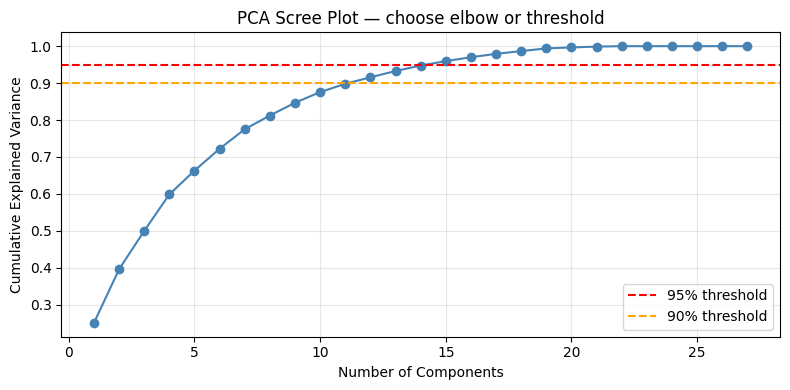

In [55]:
from sklearn.decomposition import PCA

# Keep 95% of variance (let PCA choose n_components)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_train_pp)
print(f'PCA: {X_train_pp.shape[1]} features → {X_pca.shape[1]} components (95% variance retained)')
print(f'Explained variance per component: {pca.explained_variance_ratio_.round(3)}')

# Scree plot — helps choose n_components visually
pca_full = PCA().fit(X_train_pp)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axhline(0.90, color='orange', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot — choose elbow or threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()